# TraceWin agent benchmark -- results and commentary

This notebook does **not** run TraceWin or train policies. It loads and comments
the artifacts already saved under [`results/benchmark`](./benchmark) and
[`results/train/rl`](./train/rl) by earlier runs of the
official `benchmark` command and of the companion
[`tracewin_agents_benchmark.ipynb`](./tracewin_agents_benchmark.ipynb)
notebook, which *does* drive TraceWin and is the right place to go if you want
new numbers.

The main artifact is `final_thesis_018_a015_s025_steps300k_tracewin.json`:
seven policies (`a2c`, `ddpg`, `ppo`, `sac`, `svg_final`, `svg_uniform`,
`td3`), each evaluated over 20 **matched-reset** episodes in the real TraceWin
environment, on the current 18-parameter ADIGE configuration. A historical
real-TraceWin Bayesian Optimization result is included under the public label
`bayesian` as a classical single-optimum reference. The folder also
keeps two older, smaller artifacts kept here as context rather than as the
headline result:

- a single-agent (`sb3_sac`) benchmark in the **fast surrogate** environment,
  with a Bayesian-Optimization reference line, and
- a standalone accuracy report for the surrogate model that backs that fast
  environment.

Section 1 starts from the training run and its learning curves; sections 2-6
cover the corresponding TraceWin campaign; sections 7-8 cover the two
older artifacts; section 9 collects the takeaways.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository_root(start=Path.cwd()):
    # Locate the repository when Jupyter starts from either the root or results/.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "beam_optimization" / "config" / "adige.py").is_file():
            return candidate
    raise FileNotFoundError("Repository root not found.")


REPO_ROOT = find_repository_root()
BENCHMARK_DIR = REPO_ROOT / "beam_optimization" / "results" / "benchmark"
TRAIN_RUN_DIR = (REPO_ROOT / "beam_optimization" / "results" / "train" / "rl"
                 / "final_thesis_018_a015_s025_steps300k")
BAYESIAN_DIR = (REPO_ROOT / "beam_optimization" / "results"
                / "bayesian_opt" / "cold_start")
assert BENCHMARK_DIR.is_dir(), f"Missing benchmark folder: {BENCHMARK_DIR}"
assert TRAIN_RUN_DIR.is_dir(), f"Missing training run: {TRAIN_RUN_DIR}"
assert BAYESIAN_DIR.is_dir(), f"Missing Bayesian folder: {BAYESIAN_DIR}"

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import PARAMETERS

# TraceWin key -> short human-readable label, e.g. "ele[2][5]" -> "AD.SO.01".
PARAM_LABELS = {p.key: p.name for p in PARAMETERS}
PARAM_DEFAULTS = {p.key: p.default for p in PARAMETERS}
PARAM_SENSITIVITY = {p.key: p.sensitivity for p in PARAMETERS}

# Keep old artifact keys readable while using the current public name.
DISPLAY_NAMES = {"svg_finale": "svg_final"}
display_name = lambda name: DISPLAY_NAMES.get(name, name)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Repository     :", REPO_ROOT)
print("Benchmark data :", BENCHMARK_DIR)
print("Training data  :", TRAIN_RUN_DIR)
print("Bayesian data  :", BAYESIAN_DIR)

Repository     : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization
Benchmark data : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark
Training data  : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/train/rl/final_thesis_018_a015_s025_steps300k
Bayesian data  : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/bayesian_opt/cold_start


## 1. Training run and learning curves

The seven policies benchmarked in the following sections come from
`final_thesis_018_a015_s025_steps300k`. The model-free agents were trained
for 300,000 environment steps on the surrogate; the SVG curves use their own
episode-based budget and therefore end earlier on the common step axis. Every
run used three seeds (42, 43, 44) and the same reward regularization:

```text
reward = score / 100
       - 0.02 * distance_penalty
       - 0.15 * action_penalty
       - 0.25 * action_smoothness_penalty
       - 5.00 * score_regression_penalty
```

The solid line is the mean evaluation score across seeds and the shaded band
shows their dispersion. These evaluations are performed on the **surrogate**:
they measure optimization and convergence during training, whereas sections
3-6 measure transfer and reliability on real TraceWin.

In [2]:
training_summary_path = TRAIN_RUN_DIR / "summary.json"
learning_curves_path = TRAIN_RUN_DIR / "learning_curves.png"
training_benchmark_path = BENCHMARK_DIR / "final_thesis_018_a015_s025_steps300k_tracewin.json"
training_summary = json.loads(training_summary_path.read_text())
training_tw = json.loads(training_benchmark_path.read_text())["policy_evaluation_tracewin"]

training_rows = []
for algorithm, values in training_summary.items():
    if not isinstance(values, dict) or "best_score_mean" not in values:
        continue
    training_rows.append({
        "algorithm": display_name(algorithm),
        "training_best_mean": values["best_score_mean"],
        "training_best_std": values["best_score_std"],
        "best_seed": values["best_seed"],
        "tracewin_final_mean": training_tw["summary"][algorithm]["final_score_mean"],
        "tracewin_final_std": training_tw["summary"][algorithm]["final_score_std"],
    })

training_comparison_df = (pd.DataFrame(training_rows)
                          .set_index("algorithm")
                          .sort_values("training_best_mean", ascending=False))
display(Markdown("**Training summary beside the real TraceWin result**"))
display(training_comparison_df.round(3))

regularization = training_summary["training_reward_regularization"]
display(Markdown("**Reward-regularization weights saved with the run**"))
display(pd.Series(regularization, name="weight").to_frame())

**Training summary beside the real TraceWin result**

,training_best_mean,training_best_std,best_seed,tracewin_final_mean,tracewin_final_std
algorithm,,,,,
svg_uniform,71.872,0.060,43,40.763,11.214
svg_final,55.612,0.540,42,-106.371,375.104
td3,50.434,0.069,43,47.934,9.906
ppo,50.236,0.195,44,-15.739,225.905
sac,50.207,0.305,42,45.095,10.288
ddpg,47.131,0.966,44,2.773,14.275
a2c,45.771,1.064,44,-697.609,460.418


**Reward-regularization weights saved with the run**

,weight
distance_penalty_weight,0.02
action_penalty_weight,0.15
action_smoothness_penalty_weight,0.25
score_regression_penalty_weight,5.00


**Aggregate learning curves (three training seeds)**

![Aggregate learning curves](./train/rl/final_thesis_018_a015_s025_steps300k/learning_curves.png)

The training curves separate two questions that the benchmark alone cannot.
`svg_uniform` and `svg_final` optimize the surrogate quickly, while `sac`
improves more slowly and stabilizes only in the latter part of training. `td3`
also reaches a stable high plateau; `a2c` and `ddpg` remain much noisier and
lower. The TraceWin columns show why training score is not sufficient for
model selection: `svg_final` looks strong on the surrogate but transfers
unreliably, whereas `td3`, `sac` and `svg_uniform` retain good final performance
on TraceWin. The two score columns deliberately are not subtracted: one is a
best surrogate-validation statistic and the other is a mean final real-machine
score, so their numerical difference would not be a like-for-like estimate of
the sim-to-real gap.

## 2. Score function and run configuration

Every artifact in this folder embeds the same `score_function` metadata, so
loading it once is enough to interpret every table and plot below. The score
is `ERROR_SCORE = -999` whenever the beam is fully lost
(`npart_ratio <= 0`); otherwise it is a weighted, linear combination of the
transmitted-particle fraction and penalties on emittance, beam offset, angle
and size, each measured against a reference value.

In [3]:
final_thesis_path = BENCHMARK_DIR / "final_thesis_018_a015_s025_steps300k_tracewin.json"
final_thesis = json.loads(final_thesis_path.read_text())

score_meta = final_thesis["score_function"]
display(Markdown(f"**Score name:** `{score_meta['name']}` (v{score_meta['version']})"))
display(Markdown(f"> {score_meta['formula']}"))
display(pd.DataFrame([score_meta["weights"]], index=["weight"]).T.rename_axis("term"))

tw = final_thesis["policy_evaluation_tracewin"]
episodes_df = pd.DataFrame(tw["episodes"])
algorithms = sorted(tw["summary"].keys())

print(f"Algorithms benchmarked : {', '.join(algorithms)}")
print(f"Episodes per algorithm : {episodes_df.groupby('algorithm').size().unique().tolist()}")
print(f"Max episode length     : {episodes_df['n_steps'].max()} steps")

**Score name:** `adige_linear_beam_quality` (v1)

> ERROR_SCORE if npart_ratio <= ALL_PARTICLES_LOST_NPART_RATIO; otherwise linear transmission reward minus emittance, offset, angle, and size penalties

,weight
term,
npart_ratio,100.0
emittance,10.0
offset,1.0
angle,1.0
size,1.0


Algorithms benchmarked : a2c, ddpg, ppo, sac, svg_finale, svg_uniform, td3
Episodes per algorithm : [20]
Max episode length     : 20 steps


## 3. Final-policy comparison (7 agents plus `bayesian`)

`final_score_mean`/`_std` describe the state the episode actually ends in --
the number that matters operationally, since that is the configuration a
policy would actually leave the machine in. `best_observed_score` is a
different, more optimistic number: the highest score seen at *any* reset or
step, even if the policy immediately moved away from it again (more on that
gap below). Because every algorithm uses the same episode seeds, comparisons
can also be made pairwise on identical starting conditions.

In [4]:
summary_df = pd.DataFrame(tw["summary"]).T
summary_df.index.name = "algorithm"
summary_cols = [
    "episodes", "final_score_mean", "final_score_std",
    "final_emittance_mean", "final_npart_ratio_mean",
    "best_observed_score", "best_observed_episode", "best_observed_step",
]
summary_display = summary_df[summary_cols].sort_values("final_score_mean", ascending=False).copy()
summary_display.index = summary_display.index.map(display_name)
display(summary_display.round(3))

,episodes,final_score_mean,final_score_std,final_emittance_mean,final_npart_ratio_mean,best_observed_score,best_observed_episode,best_observed_step
algorithm,,,,,,,,
td3,20,47.934371,9.905809,0.055402,0.486885,64.785174,12,20
sac,20,45.095224,10.28803,0.055272,0.4756,61.472307,7,18
svg_uniform,20,40.7629,11.213522,0.053103,0.4179,57.792484,12,20
ddpg,20,2.773341,14.275258,0.046697,0.19249,42.501201,16,7
ppo,20,-15.738505,225.904816,0.048011,0.35149,61.267796,12,18
svg_final,20,-106.371236,375.103891,0.04691,0.434055,63.368742,7,20
a2c,20,-697.608678,460.417778,0.015386,0.07778,33.38563,2,0


### `bayesian`: classical TraceWin optimization reference

`bayesian` is the completed classical optimization campaign: 64 Sobol
initial points followed by 100 Gaussian-Process-guided evaluations, all run
directly in TraceWin. Its value below is the **best selected configuration**
among 164 evaluations, not a mean over 20 matched-reset episodes. It is
therefore shown alongside the agents as a reference, but is deliberately not
inserted into their mean/std ranking or boxplots.

The historical artifact also used the former failure rule
`npart_ratio < 0.1`, whereas the current benchmark assigns `ERROR_SCORE` only
at total beam loss. The reported optimum was a successful simulation and uses
the same continuous beam-quality terms, but the campaign metadata is not
strictly identical to the current policy benchmark.

In [5]:
bayesian_path = BAYESIAN_DIR / "bayesian_opt_cold_start.json"
bayesian_report = json.loads(bayesian_path.read_text())
bayesian_evaluations = [
    evaluation
    for run in bayesian_report["runs"]
    for evaluation in run["evaluations"]
]
bayesian_best = bayesian_report["best_result"]
bayesian_default = bayesian_report.get("default_result") or {}
bayesian_reference_df = pd.DataFrame([{
    "method": "bayesian",
    "tracewin_evaluations": len(bayesian_evaluations),
    "successful_evaluations": sum(bool(row.get("success")) for row in bayesian_evaluations),
    "sobol_evaluations": sum(row.get("phase") == "sobol" for row in bayesian_evaluations),
    "guided_evaluations": sum(row.get("phase") == "bayesian" for row in bayesian_evaluations),
    "best_tracewin_score": bayesian_best["score"],
    "best_evaluation": bayesian_best["evaluation_index"],
    "bounds_scale": bayesian_report["config"]["bounds_scale"],
    "default_score": bayesian_default.get("score") if bayesian_default.get("success") else np.nan,
    "statistic": "selected best (not episode mean)",
}]).set_index("method")
display(bayesian_reference_df.round(3))

,tracewin_evaluations,successful_evaluations,sobol_evaluations,guided_evaluations,best_tracewin_score,best_evaluation,bounds_scale,default_score,statistic
method,,,,,,,,,
bayesian,164,153,64,100,47.535,91,0.35,NaN,selected best (not episode mean)


**`bayesian` convergence on real TraceWin evaluations**

![Bayesian TraceWin convergence](./bayesian_opt/cold_start/bayesian_opt_cold_start_convergence.png)

The selected best score is **47.535** after 164 real evaluations (153
successful and 11 failed). Numerically it lies in the same range as the best
agent means, but it answers a different question: the curve records the best
configuration discovered during optimization, while the policy table measures
how reliably each trained controller ends from 20 randomized matched resets.

**Reading the ranking:**

- **`td3`, `sac`, `svg_uniform`** form the top cluster: final score in the
  +40-48 range with the tightest spreads (std ~10), and the best transmitted
  fractions (`final_npart_ratio_mean` ~0.42-0.49). These are the three
  policies that reliably leave the machine in a good state.
- **`ddpg`** lands close to zero mean score with a comparatively large std --
  it neither fails outright nor consistently finds a good configuration.
- **`ppo`** and **`svg_final`** (stored as `svg_finale` in this legacy artifact) have slightly *negative* mean scores with
  very large std (225 and 375). A negative mean next to a competitive
  `best_observed_score` (61.3 and 63.4, both near the top of the whole table)
  is the signature of a policy that *can* reach good states but does not do
  so reliably -- section 4 quantifies this with an explicit failure rate.
- **`a2c`** is the outlier: mean final score of -698 with std 460, i.e. most
  episodes end near `ERROR_SCORE = -999` (total particle loss).

**Bar plot** (mean +/- std per algorithm) -- `benchmark_policy_bars_tracewin.png`

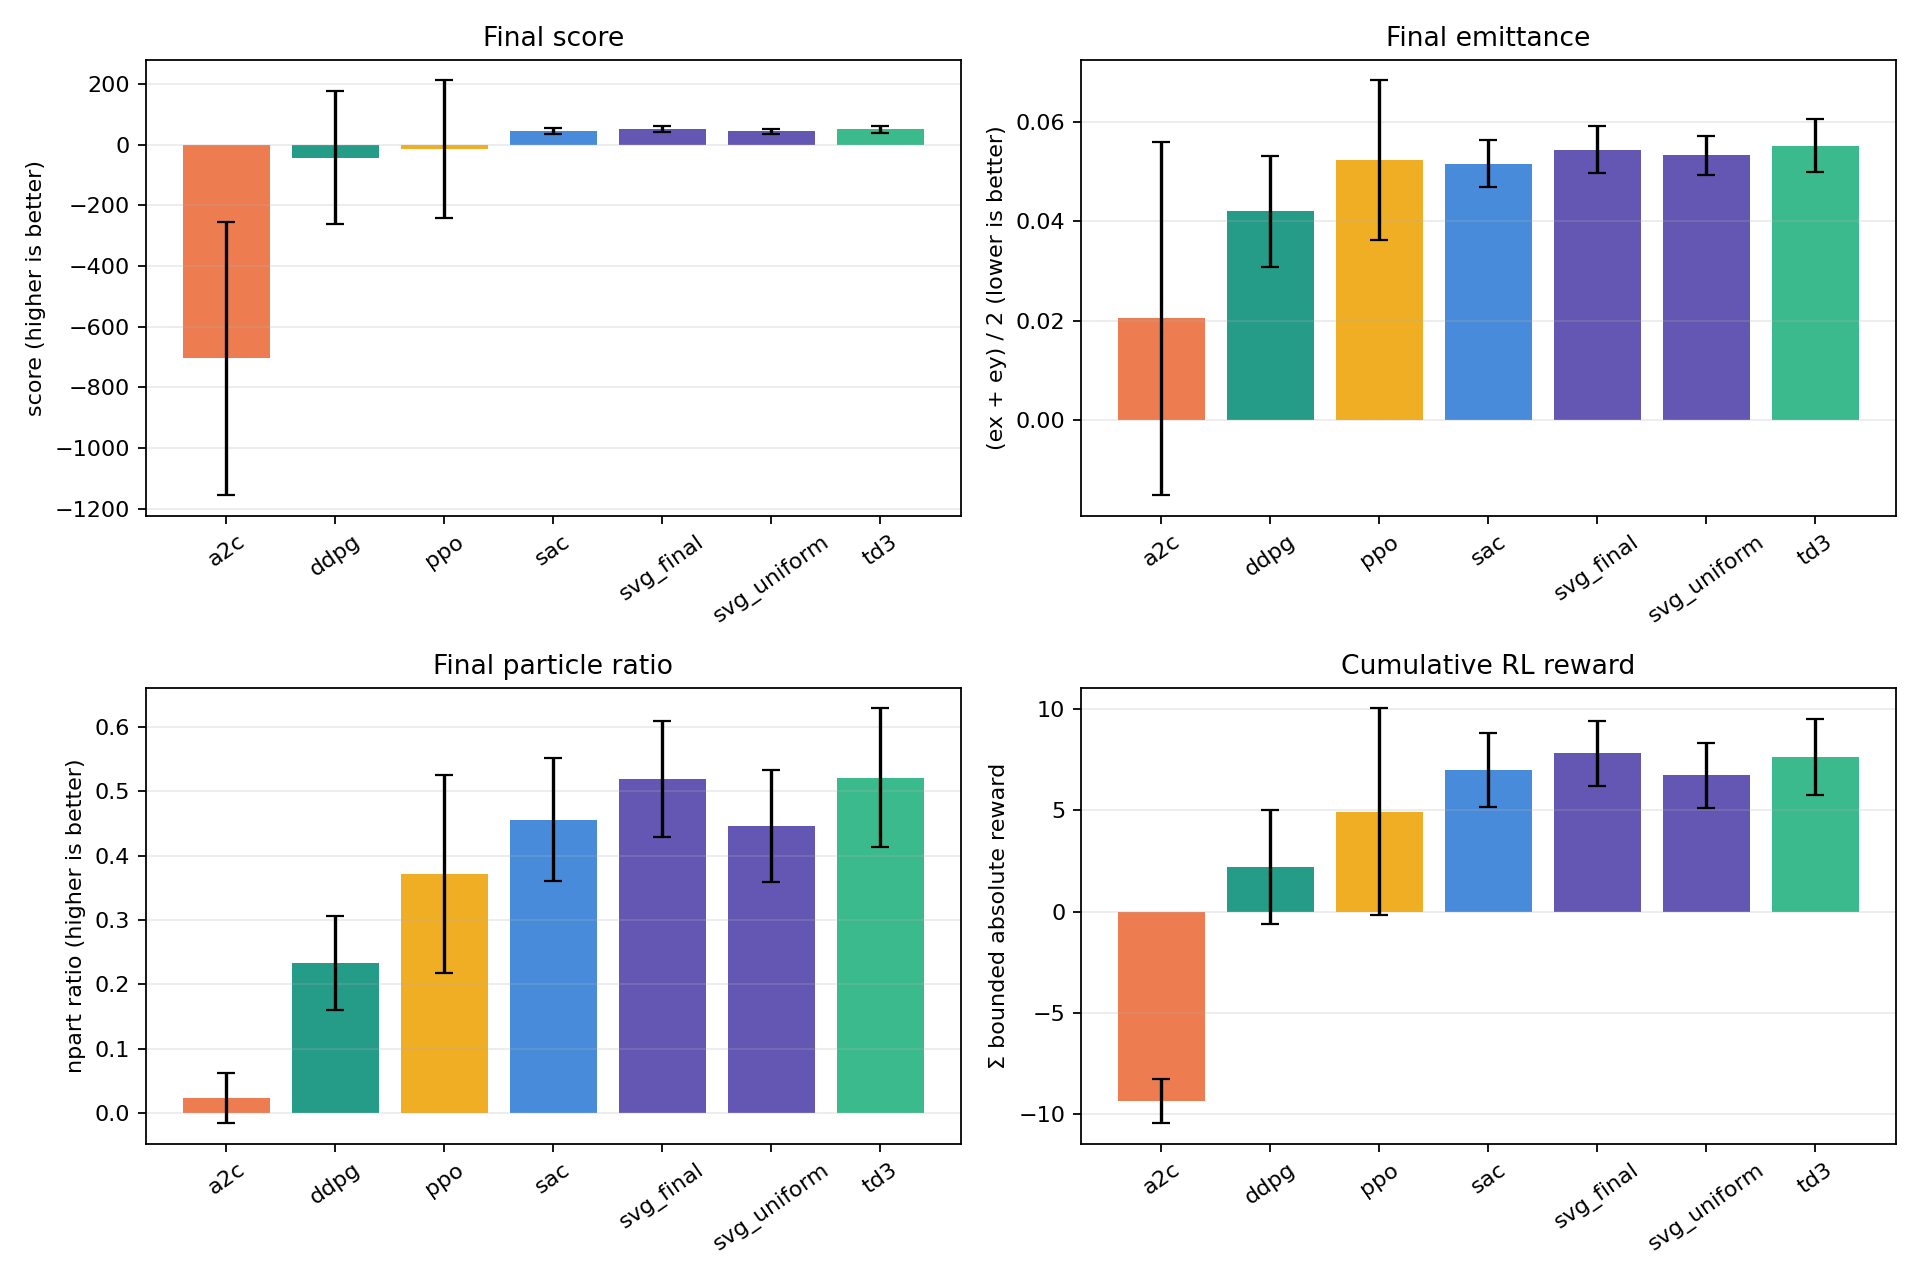

**Box plot** (per-episode spread per algorithm) -- `benchmark_policy_boxplots_tracewin.png`

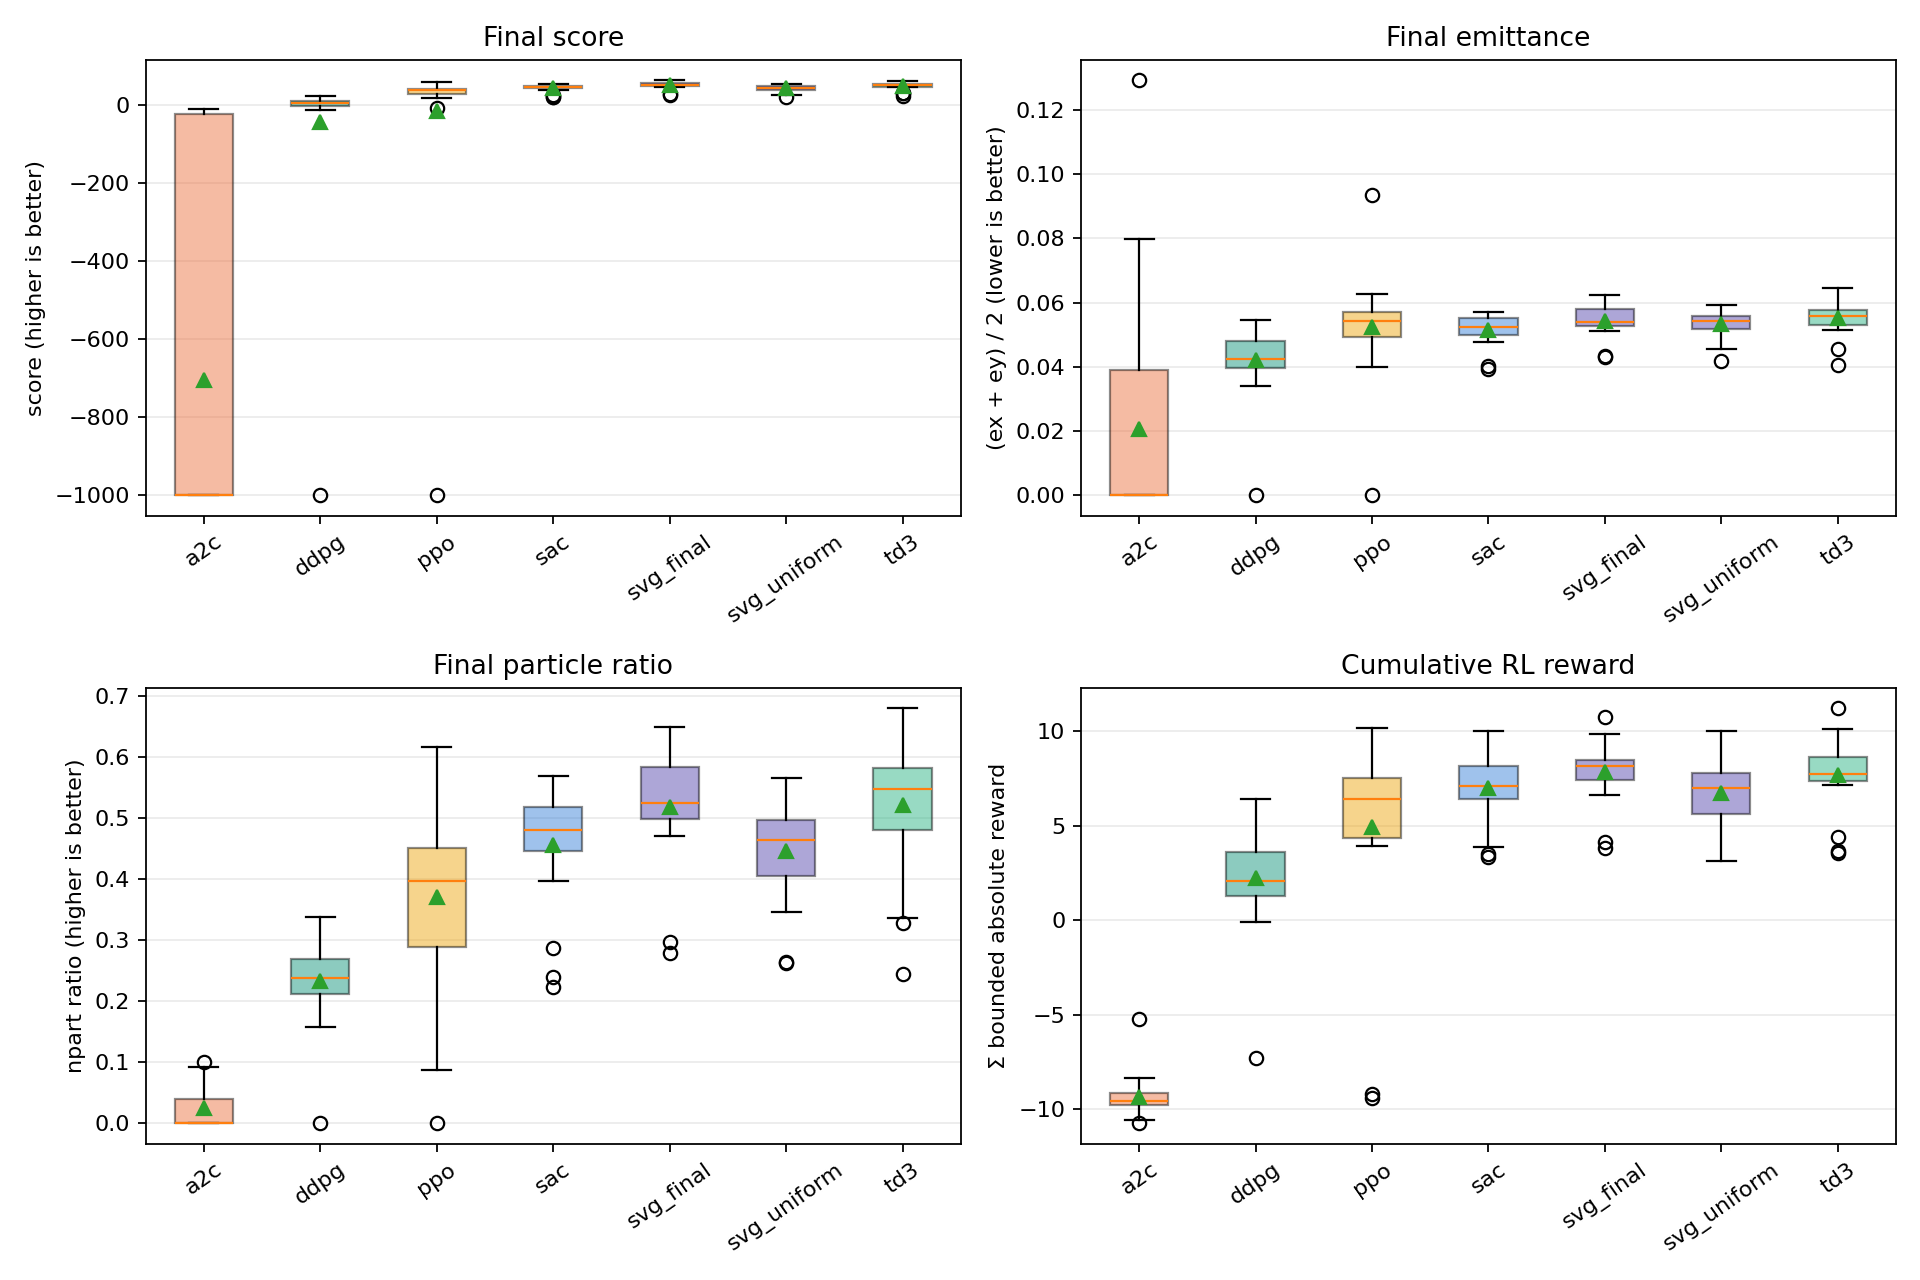

In [6]:
bar_plot = BENCHMARK_DIR / "benchmark_policy_bars_tracewin.png"
box_plot = BENCHMARK_DIR / "benchmark_policy_boxplots_tracewin.png"

display(Markdown(f"**Bar plot** (mean +/- std per algorithm) -- `{bar_plot.name}`"))
display(Image(filename=str(bar_plot)))
display(Markdown(f"**Box plot** (per-episode spread per algorithm) -- `{box_plot.name}`"))
display(Image(filename=str(box_plot)))

Both figures share four panels -- `final_score`, `final_emittance`,
`final_npart_ratio`, `total_reward` (the RL reward accumulated over the
episode, on its own bounded scale, not the physical score). The box plot is
the more informative of the two here: the circles below each `a2c`, `ppo` and
`svg_final` box are individual failed episodes pinned at the `-999`/`0`
floor, which is exactly what drags their bar-plot means down and inflates
their error bars -- the bar plot alone cannot distinguish "moderately
mediocre every time" from "excellent most of the time, catastrophic
occasionally," but the box plot can.

## 4. Why the error bars are so large: per-episode failure rate

A `final_score` at the `-999` floor means `npart_ratio <= 0` -- the episode
ended with the beam fully lost. Splitting each algorithm's 20 episodes into
"reached the floor" vs. "did not" turns the qualitative box-plot reading above
into a single reliability number per algorithm.

,episodes,failed_episodes,failure_rate,mean_steps_survived
algorithm,,,,
a2c,20,14,0.70,12.60
ddpg,20,0,0.00,19.30
ppo,20,1,0.05,19.25
sac,20,0,0.00,20.00
svg_final,20,3,0.15,18.00
svg_uniform,20,0,0.00,20.00
td3,20,0,0.00,20.00


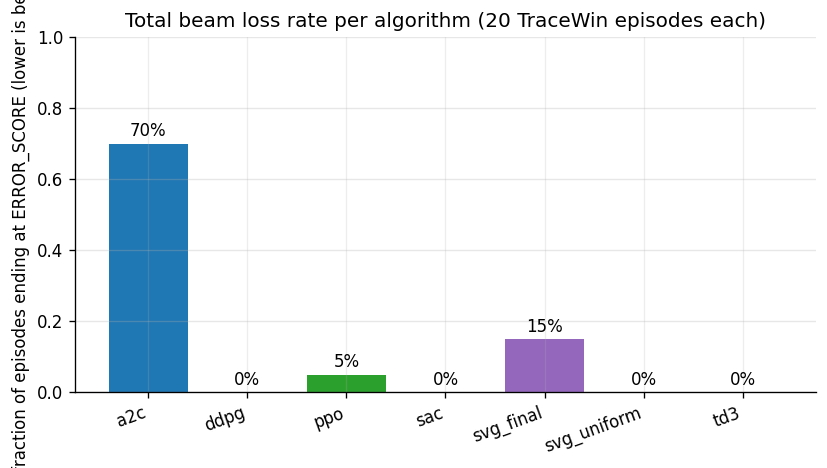

In [7]:
import matplotlib.pyplot as plt

ERROR_SCORE = score_meta["error_score"]

reliability_df = (
    episodes_df.groupby("algorithm")[["final_score", "n_steps"]]
    .apply(lambda g: pd.Series({
        "episodes": len(g),
        "failed_episodes": int((g["final_score"] <= ERROR_SCORE).sum()),
        "failure_rate": (g["final_score"] <= ERROR_SCORE).mean(),
        "mean_steps_survived": g["n_steps"].mean(),
    }), include_groups=False).loc[algorithms]
)
reliability_df["failed_episodes"] = reliability_df["failed_episodes"].astype(int)
reliability_df["episodes"] = reliability_df["episodes"].astype(int)
reliability_display = reliability_df.copy()
reliability_display.index = reliability_display.index.map(display_name)
display(reliability_display.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][: len(algorithms)]
ax.bar([display_name(name) for name in reliability_df.index], reliability_df["failure_rate"], color=colors)
ax.set_ylabel("fraction of episodes ending at ERROR_SCORE (lower is better)")
ax.set_title("Total beam loss rate per algorithm (20 TraceWin episodes each)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(reliability_df["failure_rate"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
plt.show()

`a2c` loses the beam entirely in **70%** of its episodes, which by itself
explains its −698 mean and 460 std in section 3 -- this is not a noisy policy,
it is a mostly-broken one on this checkpoint. `svg_final` (legacy artifact
key: `svg_finale`, 15%) and `ppo`
(5%) fail occasionally, enough to pull their means below zero despite
competitive best-case scores. `ddpg`, `sac`, `svg_uniform` and `td3` never
lose the beam in this batch of episodes, which is a necessary (if not
sufficient) condition for the tight error bars they show in section 3.

## 5. Statistical robustness and matched-reset comparison

Mean ± standard deviation alone is difficult to interpret when a few runs
hit the `-999` failure floor. The table and thesis-ready figure below add
bootstrap 95% confidence intervals, median/IQR, success-conditioned score,
Wilson intervals for beam-loss rate, and paired score differences. Pairing
is justified because episode *i* uses the same reset seed for every policy.
These intervals describe this 20-reset campaign; they are not guarantees for
all possible machine conditions.

**Matched-reset reference:** `td3` (highest mean final score)

,mean_score,mean_ci95_low,mean_ci95_high,median_score,q1_score,q3_score,iqr,mean_if_beam_survives,survival_mean_ci95_low,survival_mean_ci95_high,failed_episodes,failure_rate,failure_ci95_low,failure_ci95_high,paired_delta_vs_td3,paired_delta_ci95_low,paired_delta_ci95_high,paired_win_rate
algorithm,,,,,,,,,,,,,,,,,,
td3,47.934,43.435,52.130,49.590,42.739,55.643,12.904,47.934,43.386,52.157,0,0.00,-0.000,0.161,0.000,0.000,0.000,0.00
sac,45.095,40.406,49.321,46.943,42.031,52.060,10.029,45.095,40.343,49.285,0,0.00,-0.000,0.161,-2.839,-7.877,2.267,0.40
svg_uniform,40.763,35.901,45.689,41.800,29.485,49.200,19.715,40.763,35.837,45.577,0,0.00,-0.000,0.161,-7.171,-11.919,-2.183,0.20
ddpg,2.773,-3.435,9.113,2.383,-10.168,11.371,21.540,2.773,-3.377,9.087,0,0.00,-0.000,0.161,-45.161,-53.116,-36.878,0.05
ppo,-15.739,-121.757,40.180,34.749,26.184,44.922,18.738,36.012,30.458,41.656,1,0.05,0.009,0.236,-63.673,-169.496,-7.938,0.15
svg_final,-106.371,-267.385,50.462,51.259,35.003,57.576,22.573,51.151,45.811,55.727,3,0.15,0.052,0.360,-154.306,-315.111,1.847,0.55
a2c,-697.609,-898.132,-495.628,-999.000,-999.000,-9.180,989.820,5.638,-2.650,13.650,14,0.70,0.481,0.855,-745.543,-945.751,-542.358,0.00


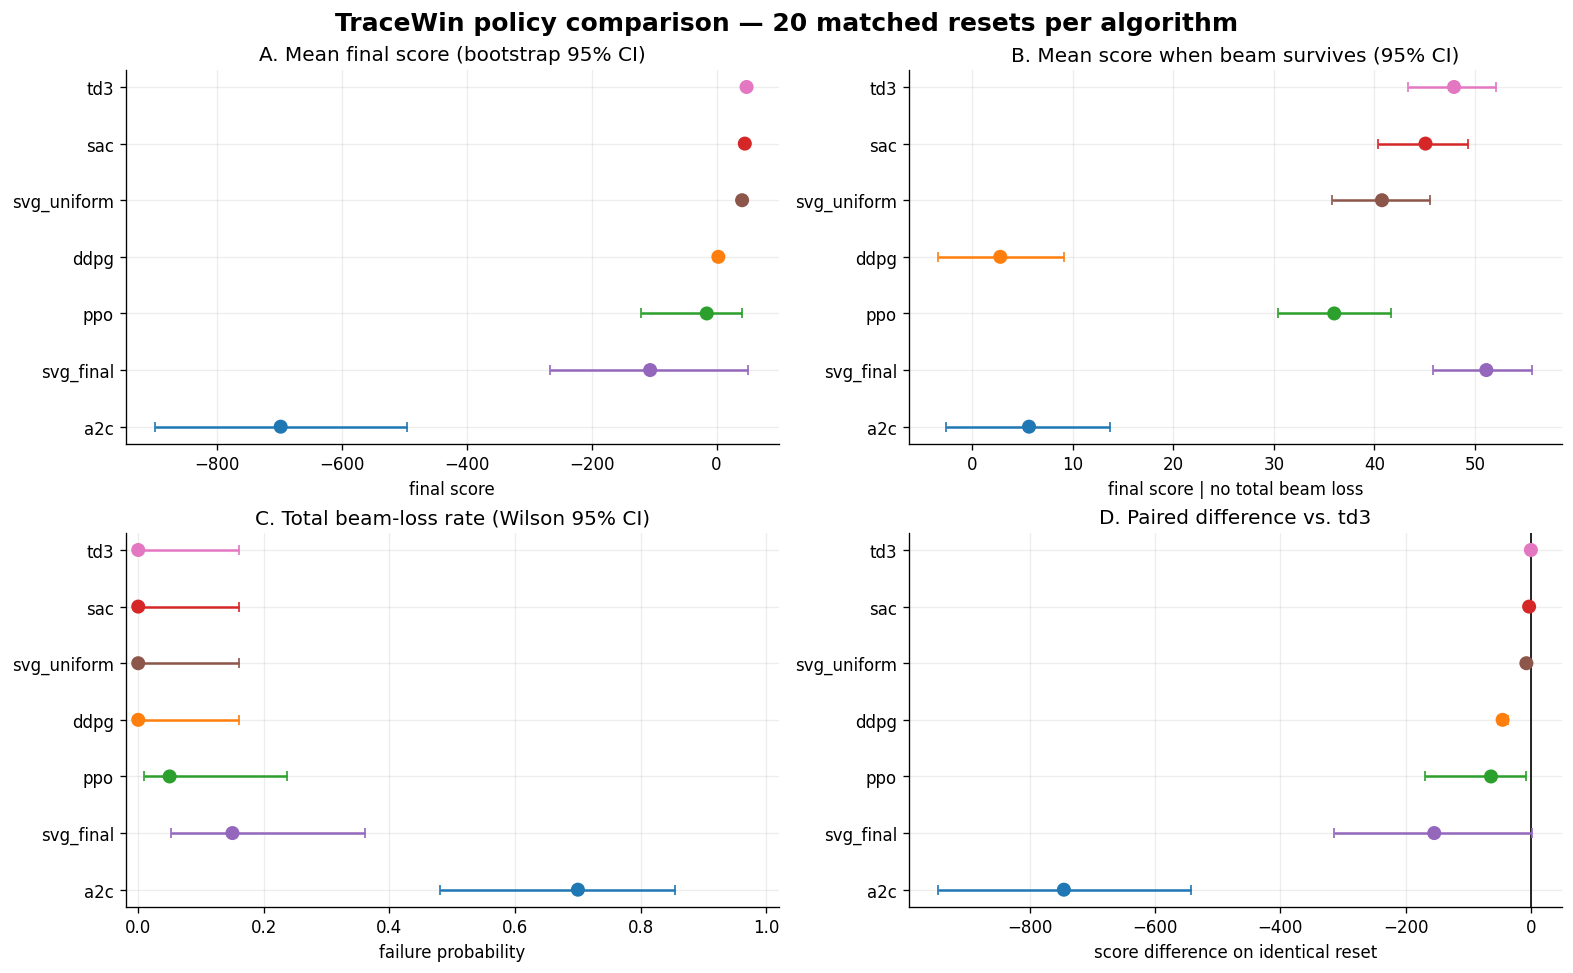

Saved thesis-ready figure: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/tracewin_policy_comparison_thesis.png


In [8]:
BOOTSTRAP_SAMPLES = 20_000
BOOTSTRAP_SEED = 20260804

def bootstrap_mean_ci(values, samples=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    means = rng.choice(values, size=(samples, len(values)), replace=True).mean(axis=1)
    return np.quantile(means, [0.025, 0.975])

def wilson_interval(successes, total, z=1.96):
    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return centre - margin, centre + margin

ranking = summary_df["final_score_mean"].sort_values().index.tolist()
paired_scores = episodes_df.pivot(index="episode", columns="algorithm", values="final_score")
reference_algorithm = summary_df["final_score_mean"].idxmax()
rows = []
for offset, algorithm in enumerate(ranking):
    values = episodes_df.loc[episodes_df.algorithm == algorithm, "final_score"].to_numpy(float)
    survived = values[values > ERROR_SCORE]
    failed = int((values <= ERROR_SCORE).sum())
    mean_lo, mean_hi = bootstrap_mean_ci(values, seed=BOOTSTRAP_SEED + offset)
    success_lo, success_hi = bootstrap_mean_ci(survived, seed=BOOTSTRAP_SEED + 200 + offset) if len(survived) else (np.nan, np.nan)
    fail_lo, fail_hi = wilson_interval(failed, len(values))
    paired_delta = (paired_scores[algorithm] - paired_scores[reference_algorithm]).to_numpy(float)
    delta_lo, delta_hi = bootstrap_mean_ci(paired_delta, seed=BOOTSTRAP_SEED + 100 + offset)
    rows.append({
        "algorithm": display_name(algorithm),
        "mean_score": values.mean(),
        "mean_ci95_low": mean_lo,
        "mean_ci95_high": mean_hi,
        "median_score": np.median(values),
        "q1_score": np.quantile(values, 0.25),
        "q3_score": np.quantile(values, 0.75),
        "iqr": np.quantile(values, 0.75) - np.quantile(values, 0.25),
        "mean_if_beam_survives": survived.mean() if len(survived) else np.nan,
        "survival_mean_ci95_low": success_lo,
        "survival_mean_ci95_high": success_hi,
        "failed_episodes": failed,
        "failure_rate": failed / len(values),
        "failure_ci95_low": fail_lo,
        "failure_ci95_high": fail_hi,
        f"paired_delta_vs_{display_name(reference_algorithm)}": paired_delta.mean(),
        "paired_delta_ci95_low": delta_lo,
        "paired_delta_ci95_high": delta_hi,
        "paired_win_rate": (paired_delta > 0).mean(),
    })

robust_df = pd.DataFrame(rows).set_index("algorithm").sort_values("mean_score", ascending=False)
display(Markdown(f"**Matched-reset reference:** `{display_name(reference_algorithm)}` (highest mean final score)"))
display(robust_df.round(3))

plot_df = robust_df.iloc[::-1]
labels = plot_df.index.tolist()
y = np.arange(len(labels))
palette = dict(zip(sorted(robust_df.index), plt.get_cmap("tab10").colors))
colors = [palette[label] for label in labels]

def horizontal_intervals(axis, centres, lows, highs):
    for yi, centre, low, high, color in zip(y, centres, lows, highs, colors):
        axis.errorbar(centre, yi, xerr=[[centre - low], [high - centre]], fmt="none", ecolor=color, capsize=3)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

mean = plot_df.mean_score.to_numpy()
horizontal_intervals(axes[0, 0], mean, plot_df.mean_ci95_low, plot_df.mean_ci95_high)
axes[0, 0].scatter(mean, y, c=colors, s=55, zorder=3)
axes[0, 0].set(yticks=y, yticklabels=labels, title="A. Mean final score (bootstrap 95% CI)", xlabel="final score")

survival_mean = plot_df.mean_if_beam_survives.to_numpy()
horizontal_intervals(axes[0, 1], survival_mean, plot_df.survival_mean_ci95_low, plot_df.survival_mean_ci95_high)
axes[0, 1].scatter(survival_mean, y, c=colors, s=55, zorder=3)
axes[0, 1].set(yticks=y, yticklabels=labels, title="B. Mean score when beam survives (95% CI)", xlabel="final score | no total beam loss")

failure = plot_df.failure_rate.to_numpy()
horizontal_intervals(axes[1, 0], failure, plot_df.failure_ci95_low, plot_df.failure_ci95_high)
axes[1, 0].scatter(failure, y, c=colors, s=55, zorder=3)
axes[1, 0].set(yticks=y, yticklabels=labels, title="C. Total beam-loss rate (Wilson 95% CI)", xlabel="failure probability", xlim=(-0.02, 1.02))

delta_col = f"paired_delta_vs_{display_name(reference_algorithm)}"
delta = plot_df[delta_col].to_numpy()
axes[1, 1].axvline(0, color="black", linewidth=1)
horizontal_intervals(axes[1, 1], delta, plot_df.paired_delta_ci95_low, plot_df.paired_delta_ci95_high)
axes[1, 1].scatter(delta, y, c=colors, s=55, zorder=3)
axes[1, 1].set(yticks=y, yticklabels=labels, title=f"D. Paired difference vs. {display_name(reference_algorithm)}", xlabel="score difference on identical reset")

fig.suptitle("TraceWin policy comparison — 20 matched resets per algorithm", fontsize=15, fontweight="bold")
thesis_plot = BENCHMARK_DIR / "tracewin_policy_comparison_thesis.png"
fig.savefig(thesis_plot, dpi=220, bbox_inches="tight")
plt.show()
print("Saved thesis-ready figure:", thesis_plot)

## 6. Best-observed configuration vs. final-policy performance

`best_observed_score` is the maximum physical score seen at any reset or step
of any episode, together with the complete 18-parameter machine configuration
that produced it (`best_observed_params`). `gain_over_final_mean` is simply
`best_observed_score - final_score_mean`: a large gain means the policy
*visits* a good configuration during the episode but does not end there --
either it keeps exploring past the optimum, or (per section 4) it sometimes
loses the beam later in the same trajectory.

In [9]:
best_rows = [
    {
        "algorithm": algo,
        "best_observed_score": values["best_observed_score"],
        "episode": values["best_observed_episode"],
        "step": values["best_observed_step"],
    }
    for algo, values in tw["summary"].items()
]
best_scores_df = pd.DataFrame(best_rows).set_index("algorithm").loc[algorithms]
best_scores_df["gain_over_final_mean"] = (
    best_scores_df["best_observed_score"] - summary_df.loc[algorithms, "final_score_mean"]
)
best_scores_display = best_scores_df.sort_values("gain_over_final_mean", ascending=False).copy()
best_scores_display.index = best_scores_display.index.map(display_name)
display(best_scores_display.round(3))

,best_observed_score,episode,step,gain_over_final_mean
algorithm,,,,
a2c,33.386,2,0,730.994308
svg_final,63.369,7,20,169.739978
ppo,61.268,12,18,77.006301
ddpg,42.501,16,7,39.72786
svg_uniform,57.792,12,20,17.029584
td3,64.785,12,20,16.850802
sac,61.472,7,18,16.377083


`svg_final` (gain ~170), `a2c` (~731) and `ppo` (~77) show the largest gaps
-- consistent with section 4, these are the same three policies with
non-zero failure rates: the average is dragged down by episodes that visit a
good state and then lose the beam anyway. `sac`, `td3` and `svg_uniform` have
the smallest gains (13-17), meaning their final state is already close to the
best state they ever see -- a much more useful property operationally than a
high best-case score alone.

In [10]:
best_params_raw = pd.DataFrame({
    algo: values["best_observed_params"] for algo, values in tw["summary"].items()
}).T.loc[algorithms]
best_params_raw.loc["bayesian"] = pd.Series(bayesian_best["params"])

best_params_df = best_params_raw.rename(columns=PARAM_LABELS)
display(Markdown("**Best-observed configuration per algorithm (human-readable parameter names)**"))
best_params_display = best_params_df.copy()
best_params_display.index = best_params_display.index.map(display_name)
display(best_params_display.round(4))

# The 18 parameters live on very different physical scales (solenoid currents
# ~0.1-0.4, quadrupole/EM-lens currents in the hundreds to thousands), so a raw
# "distance from default" is not comparable across columns. ParameterSpec.sensitivity
# is calibrated as "the delta in this parameter that moves the score by ~1 point",
# so dividing by it expresses every deviation on the same, score-relative scale.
default_row = pd.Series(PARAM_DEFAULTS)
sensitivity_row = pd.Series(PARAM_SENSITIVITY)
normalized_deviation = (
    (best_params_raw - default_row).abs().div(sensitivity_row).rename(columns=PARAM_LABELS)
)
display(Markdown(
    "**Deviation from the nominal ADIGE default, in score-point-equivalents "
    "(`|best - default| / sensitivity`)**"
))
normalized_deviation_display = normalized_deviation.copy()
normalized_deviation_display.index = normalized_deviation_display.index.map(display_name)
display(normalized_deviation_display.round(2))
display(Markdown("Mean score-point-equivalent deviation per algorithm:"))
mean_deviation = normalized_deviation.mean(axis=1).rename(index=display_name)
display(mean_deviation.round(2).sort_values().rename("mean_deviation"))

**Best-observed configuration per algorithm (human-readable parameter names)**

,AD.SO.01,AD.SO.02,AD.MS.03.X,AD.MS.03.Y,AD.1EQ.01,AD.MS.04.X,AD.MS.04.Y,AD.1EQ.02,AD.D.02,AD.EM.6,AD.EM.8,AD.EM.10,AD.EM.12,AD.D.03,AD.1EQ.03,AD.MS.05.X,AD.MS.05.Y,AD.1EQ.04
a2c,0.4318,0.1013,0.0,0.0,203.9972,0.0001,-0.0000,-16.4375,-0.0462,-3404.6392,-1272.7697,-520.1113,-636.1358,0.0462,10.9641,0.0000,-0.0002,-184.4459
ddpg,0.4305,0.0996,0.0,0.0,217.6416,-0.0000,0.0002,-4.8757,-0.0463,484.1122,-1902.0946,-1180.5567,611.1100,0.0462,-0.5323,0.0000,0.0002,-140.2737
ppo,0.4315,0.1028,-0.0,0.0,185.5780,0.0000,-0.0002,-17.3854,-0.0461,-2260.3893,-303.7925,-1493.3028,-270.0313,0.0462,4.9934,0.0001,-0.0001,-160.3588
sac,0.4314,0.1015,0.0,-0.0,183.9266,0.0000,-0.0002,-29.1463,-0.0461,-978.3505,-1846.9730,-712.5569,1047.6003,0.0462,6.7253,0.0000,-0.0001,-178.2017
svg_final,0.4315,0.1040,-0.0,-0.0,191.4962,-0.0000,-0.0002,-19.9641,-0.0461,-1042.4763,-1878.9371,-557.2672,2068.1201,0.0462,12.7540,0.0000,-0.0001,-199.8575
svg_uniform,0.4309,0.1014,-0.0,0.0,185.6890,0.0000,-0.0001,-7.2069,-0.0461,-1534.5556,-266.8685,-1448.7643,-160.8933,0.0462,2.6815,-0.0000,-0.0002,-153.3895
td3,0.4315,0.1006,0.0,0.0,167.0050,-0.0000,-0.0002,-11.6512,-0.0461,-1235.0527,-1445.6058,-931.9757,-1553.1653,0.0462,9.9640,-0.0001,-0.0001,-96.0890
bayesian,0.4311,0.1011,0.0,-0.0,192.3082,-0.0000,0.0000,-7.9327,-0.0462,-234.6021,-1794.1476,-595.8946,-1.5968,0.0462,5.5648,-0.0000,0.0000,-193.1801


**Deviation from the nominal ADIGE default, in score-point-equivalents (`|best - default| / sensitivity`)**

,AD.SO.01,AD.SO.02,AD.MS.03.X,AD.MS.03.Y,AD.1EQ.01,AD.MS.04.X,AD.MS.04.Y,AD.1EQ.02,AD.D.02,AD.EM.6,AD.EM.8,AD.EM.10,AD.EM.12,AD.D.03,AD.1EQ.03,AD.MS.05.X,AD.MS.05.Y,AD.1EQ.04
a2c,0.87,0.06,0.20,0.68,0.49,0.35,0.23,0.61,0.23,0.31,0.50,0.13,0.45,0.16,0.43,0.11,0.47,0.16
ddpg,0.77,0.54,0.14,0.55,1.07,0.00,1.18,0.22,0.29,0.07,0.10,0.98,0.43,0.36,0.48,0.07,0.55,0.95
ppo,0.50,0.60,0.21,2.13,0.28,0.06,1.42,0.68,0.40,0.20,1.42,1.50,0.19,1.57,0.05,0.16,0.36,0.59
sac,0.32,0.13,0.04,0.05,0.35,0.03,1.40,1.52,0.37,0.07,0.05,0.20,0.74,1.39,0.09,0.07,0.16,0.27
svg_final,0.48,1.00,0.04,0.61,0.03,0.00,1.26,0.86,0.35,0.08,0.08,0.06,1.46,0.72,0.57,0.08,0.25,0.12
svg_uniform,0.25,0.11,0.04,1.00,0.28,0.02,0.95,0.05,0.25,0.13,1.45,1.43,0.11,0.48,0.23,0.05,0.37,0.72
td3,0.42,0.18,0.24,0.74,1.07,0.05,1.54,0.27,0.44,0.10,0.33,0.56,1.09,0.66,0.35,0.09,0.32,1.75
bayesian,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Mean score-point-equivalent deviation per algorithm:

bayesian       0.00
a2c            0.36
sac            0.40
svg_uniform    0.44
svg_final      0.45
ddpg           0.49
td3            0.57
ppo            0.68
Name: mean_deviation, dtype: float64

Raw absolute deviations are misleading here: solenoid/steerer parameters live
around 0.1-0.4 while the electromagnet-lens parameters (`AD.EM.*`) live in
the hundreds to thousands, so an absolute-value table is dominated entirely
by the latter. Normalizing each deviation by that parameter's `sensitivity`
(the delta calibrated to move the score by ~1 point) puts all 18 parameters
on the same, score-relative scale. On that scale every algorithm's
best-observed point sits within roughly half a score-point-equivalent of the
nominal ADIGE default on average (0.36-0.68), and no single parameter or
algorithm stands out as a qualitatively different regime -- consistent with
this being a *fine-tuning* task around a working machine setup rather than a
search for a qualitatively different configuration. `ppo` has the largest
mean deviation (0.68), matching its unstable behavior in sections 3-5; `a2c`
being lowest here is not a sign of good tuning -- most of its "best" points
come from very early, near-default resets before the beam is lost.

## 7. Context: an earlier surrogate-environment benchmark

`benchmark_policy_summary.csv` / `benchmark_policy_episodes.csv` and the
(non-`_tracewin`-suffixed) bar/box plots come from an earlier, single-agent
run: `sb3_sac` evaluated over 50 episodes in the **fast surrogate**
environment rather than in TraceWin. The bar plot additionally overlays a
`bayesian_opt best` reference line, i.e. the best score found by the
Bayesian-Optimization search under `results/bayesian_opt/`.

This predates the multi-algorithm TraceWin campaign in sections 2-6 above and
is not on the same footing: different environment (surrogate vs. real
TraceWin), different checkpoint, and a 2.5x larger episode budget. Treat it as
a historical reference point, not as a `sac` row to append to the section 3
table.

,episodes,total_reward_mean,total_reward_std,final_score_mean,final_score_std,final_emittance_mean,final_emittance_std,final_npart_ratio_mean,final_npart_ratio_std
algorithm,,,,,,,,,
sb3_sac,50,6.402,2.75,42.851,11.961,0.05,0.004,0.445,0.109


**Surrogate-environment bar plot** -- `benchmark_policy_bars.png`

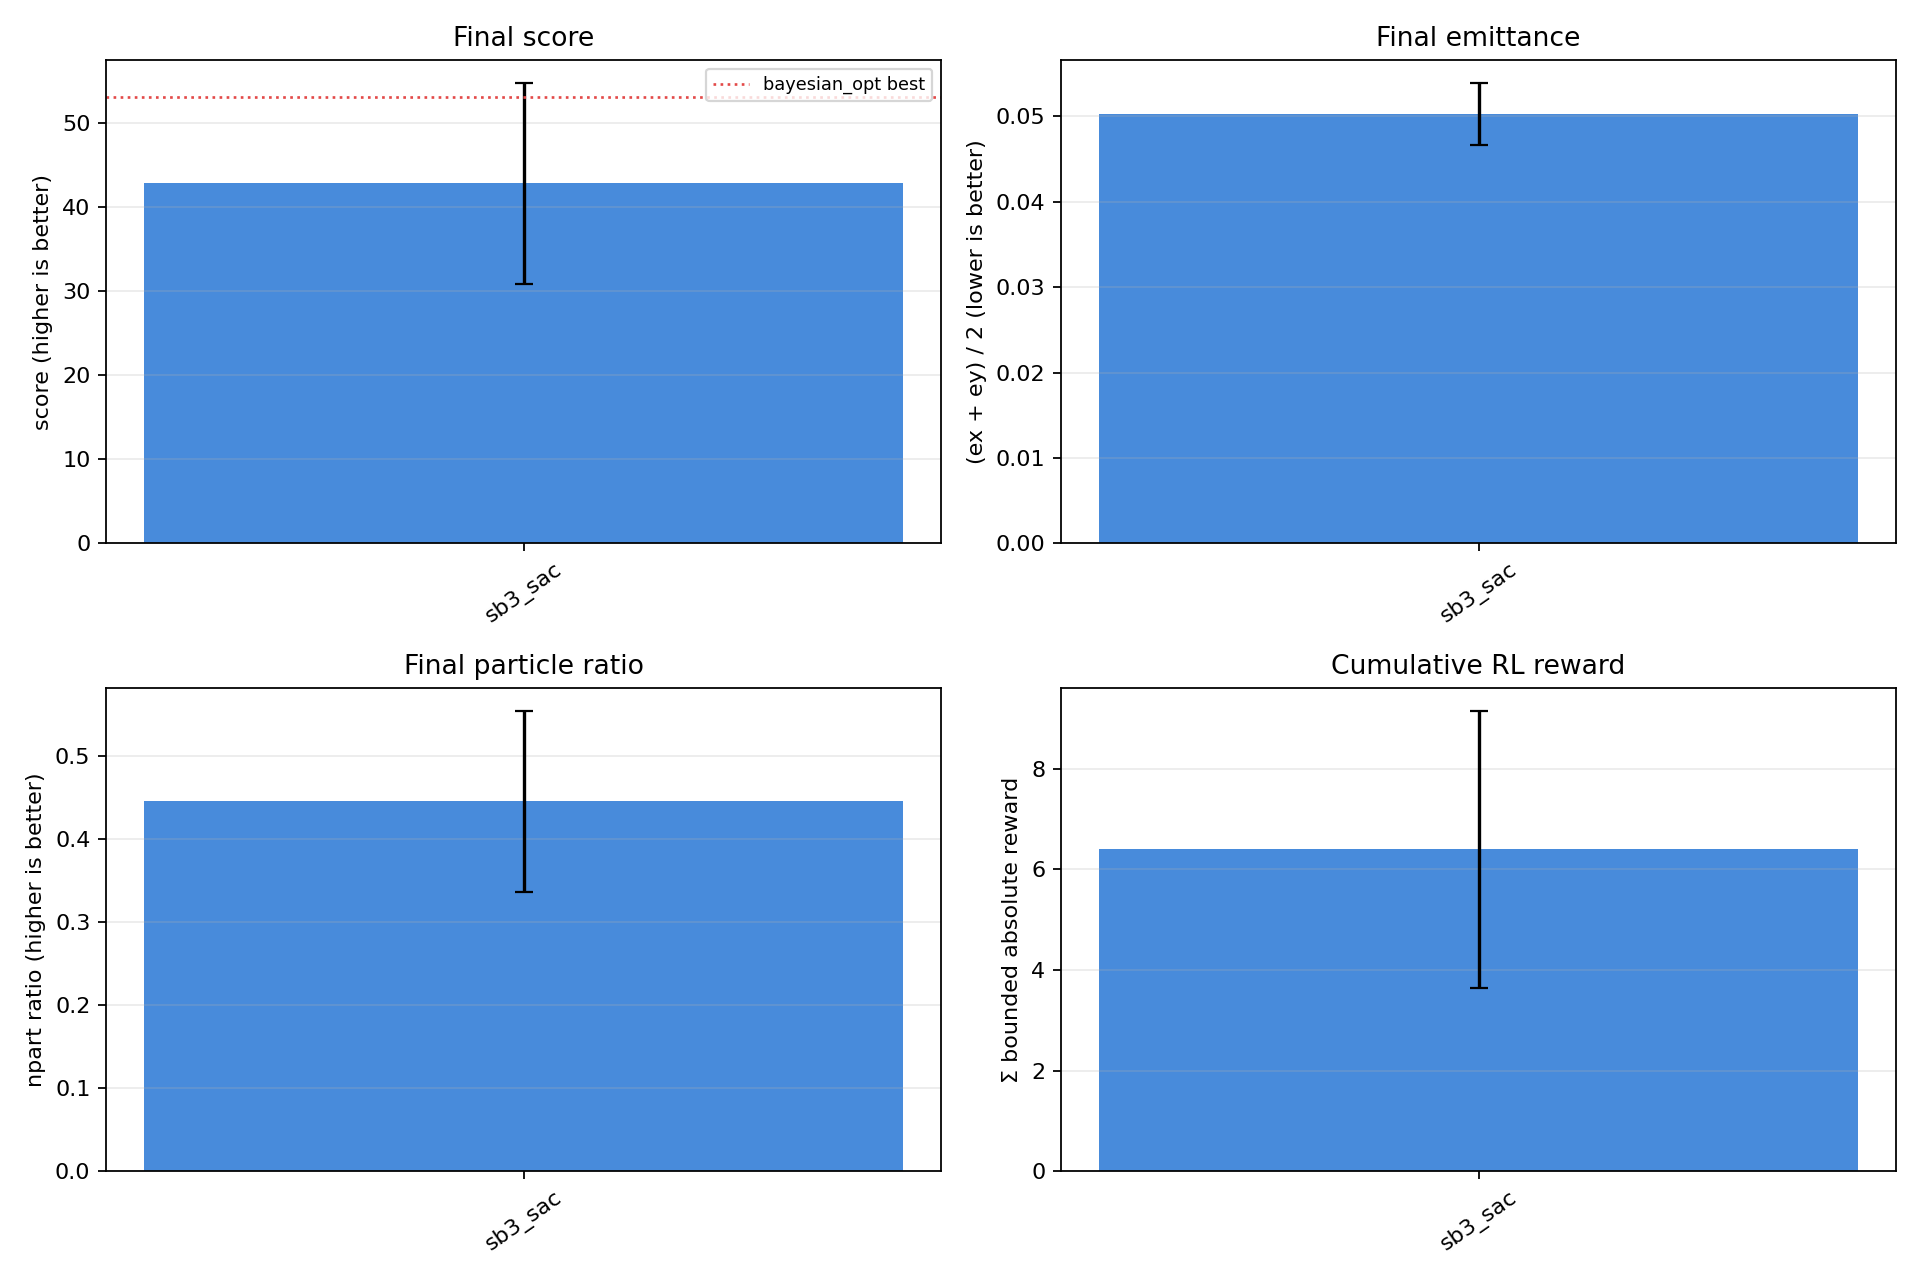

In [11]:
surrogate_summary_df = pd.read_csv(BENCHMARK_DIR / "benchmark_policy_summary.csv").set_index("algorithm")
display(surrogate_summary_df.round(3))

surrogate_bar_plot = BENCHMARK_DIR / "benchmark_policy_bars.png"
display(Markdown(f"**Surrogate-environment bar plot** -- `{surrogate_bar_plot.name}`"))
display(Image(filename=str(surrogate_bar_plot)))

`sb3_sac` averages ~43 in the surrogate environment against a Bayesian
Optimization best of ~53 (the red line) -- a reasonable but not yet
BO-matching result, obtained without any per-machine search at inference
time. Note the surrogate-environment score and the TraceWin `sac` score in
section 3 (~45) are not directly comparable: same algorithm family, different
checkpoint and evaluation environment.

## 8. Surrogate model quality backing the fast environment

`surrogate_eval.json` and `surrogate_eval_plots/` report held-out regression
accuracy for the historical surrogate used by the fast environment.


Model dir   : beam_optimization/env/surrogate_env/surrogate/trained_models/base
Dataset used: beam_optimization/env/dataset/013/dataset_test.pt


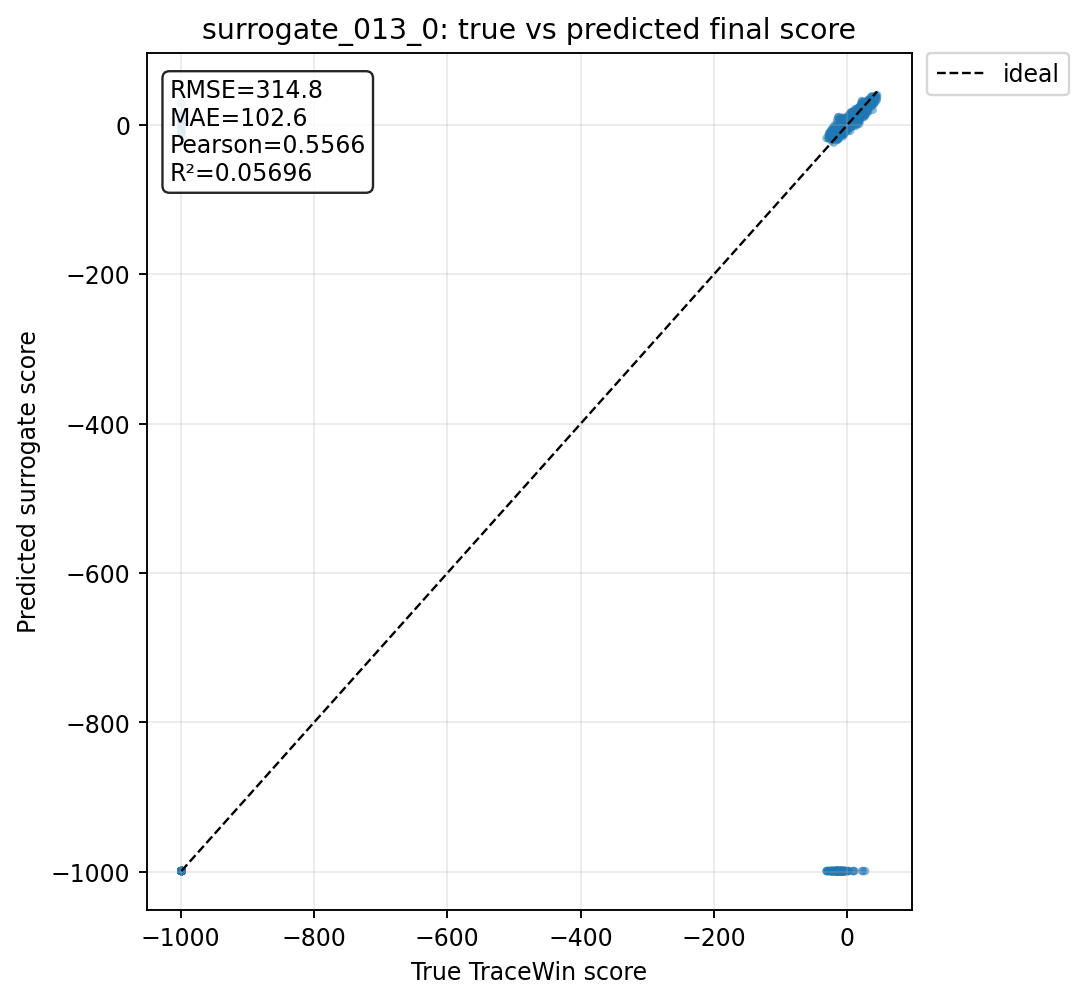

In [12]:
surrogate_eval = json.loads((BENCHMARK_DIR / "surrogate_eval.json").read_text())
print("Model dir   :", surrogate_eval["model_dir"])
print("Dataset used:", surrogate_eval["dataset_path"])

scatter_plot = BENCHMARK_DIR / "surrogate_eval_plots" / "surrogate_013_0_score_scatter.png"
display(Image(filename=str(scatter_plot)))


The historical regression head is a useful coarse approximation but is not a
substitute for TraceWin when ranking already-good configurations: on this split,
R² was 0.057 and Pearson correlation was 0.56.

**Caveat:** this report used dataset `013`, which predates the current
18-parameter ADIGE configuration. Re-run `commands/evaluate_surrogate.sh`
against the current dataset/model for an up-to-date evaluation.


## 9. Takeaways

- In the real TraceWin environment, **`td3`, `sac` and `svg_uniform`** are
  the most reliable final policies: final score ~40-48, no total-beam-loss
  episodes in this batch, and the smallest gap between their best-observed
  and final scores.
- **`a2c`** is effectively broken on this checkpoint (70% total-beam-loss
  rate); its poor mean score is a reliability problem, not a precision one.
- **`ppo`** and **`svg_final`** occasionally reach competitive scores
  (best-observed near the top of the table) but fail 5-15% of episodes,
  which is what makes their mean final score negative despite that.
- **`ddpg`** is the middle case: no catastrophic failures, but a final score
  close to zero -- it survives without particularly optimizing.
- Every algorithm's best-observed configuration sits close to the nominal
  ADIGE defaults, confirming this is a fine-tuning task, not a search for a
  qualitatively different machine setup.
- The learning curves show that surrogate convergence alone does not guarantee
  real-machine reliability: `svg_final` is the clearest counterexample, while
  `td3`, `sac` and `svg_uniform` combine good training with robust transfer.
- **`bayesian`** found a real-TraceWin score of 47.535 in 164 evaluations. This
  is a selected optimum rather than a 20-episode mean and comes from the legacy
  failure threshold, so it is retained as a classical reference rather than
  ranked as an eighth policy.
- The surrogate-environment / Bayesian-Optimization comparison and the
  surrogate accuracy report (sections 7-8) are older artifacts, useful as
  context but evaluated on a different checkpoint/dataset than the main
  TraceWin campaign above.

To generate new numbers instead of reading these, use
[`tracewin_agents_benchmark.ipynb`](./tracewin_agents_benchmark.ipynb) (single
checkpoint, real TraceWin) or the `benchmark` command directly.